# IIC2115 – Programación como Herramienta  
## Ejercicio Formativo 1 (Cap. 3) — Modelos Predictivos

**Estudiante:** Florencia Corta  
**Fecha:** _(ejecutar hoy)_  
**Dataset:** `E1_datos.csv` (pingüinos: especie, isla, medidas morfométricas y sexo)

### Objetivo general
Practicar el flujo de preparación de datos para ML: completar información faltante y dejar una base limpia y consistente para modelado posterior.

### Estructura del notebook
1. **Misión 1 — Completando información:**  
   - Imputar **valores faltantes numéricos** con la **media** de su columna.  
   - **Eliminar registros** con faltantes en **variables categóricas** (`species`, `island`, `sex`).
2. **Misión 2 — Preparación de datos:** codificación, split train/test, escalamiento.  
3. **Misión 3 — Reducción y visualización:** PCA/t-SNE.  
4. **Misión 4 — Clustering:** codo + análisis.  
5. **Misión 5 — Predicción de especie:** comparación de estrategias.



## Misión 1 — Completando información (imputación + limpieza)

**Propósito.** Dejar el dataset **sin NA numéricos** (imputados con la **media**) y **sin NA categóricos** (filas descartadas si faltan etiquetas).

**Entradas:** `E1_datos.csv`  
**Salidas:** `df_clean_m1` en memoria y archivo `E1_datos_m1.csv` en disco.

**Pasos:**
1) Cargar CSV y auditar faltantes.  
2) Identificar **columnas numéricas** y rellenar `NaN` con `mean(col)`.  
3) Definir **columnas categóricas** (`species`, `island`, `sex`) y **dropna** en esas columnas.  
4) Reportar **shapes antes/después**, conteos de NA y guardar CSV limpio.  
5) **Tests visibles**: verificar que no queden NA numéricos ni NA en categóricas.


In [1]:
# === M1.1: Imports, carga robusta y auditoría de faltantes ===
import pandas as pd
import numpy as np

# Mostrar más compacto
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

# Intento 1: leer directo (si ya subiste el archivo a Colab)
CSV_NAME = "E1_datos.csv"
try:
    df = pd.read_csv(CSV_NAME)
except FileNotFoundError:
    # Intento 2: pedir subida interactiva
    try:
        from google.colab import files  # type: ignore
        print(f"No se encontró {CSV_NAME}. Súbelo desde tu equipo…")
        _ = files.upload()
        df = pd.read_csv(CSV_NAME)
    except Exception as e:
        raise FileNotFoundError(f"No logré abrir {CSV_NAME}. Error: {e}")

print("=== Auditoría inicial ===")
print("Shape:", df.shape)
na_count = df.isna().sum().sort_values(ascending=False)
print("NA por columna:\n", na_count)

# Guardamos nombre de columnas para usar luego
all_cols = df.columns.tolist()
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in ["species", "island", "sex"] if c in df.columns]

print("\nColumnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)


No se encontró E1_datos.csv. Súbelo desde tu equipo…


Saving E1_datos.csv to E1_datos.csv
=== Auditoría inicial ===
Shape: (344, 8)
NA por columna:
 flipper_length_mm    36
sex                  10
culmen_length_mm      2
culmen_depth_mm       2
body_mass_g           2
island                0
Unnamed: 0            0
species               0
dtype: int64

Columnas numéricas: ['Unnamed: 0', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
Columnas categóricas: ['species', 'island', 'sex']


In [2]:
# === M1.2: Imputación en numéricas con media y drop de NA en categóricas ===
df_imp = df.copy()

# Imputación con media (columna a columna)
means = df_imp[num_cols].mean(numeric_only=True)
df_imp[num_cols] = df_imp[num_cols].fillna(means)

# Drop de filas con NA en categóricas clave
before = df_imp.shape[0]
df_clean_m1 = df_imp.dropna(subset=cat_cols)
after = df_clean_m1.shape[0]

print("=== Resumen Misión 1 ===")
print(f"Filas originales: {df.shape[0]}")
print(f"Filas tras imputación numérica: {df_imp.shape[0]} (no cambia el número de filas)")
print(f"Filas tras eliminar NA en categóricas {cat_cols}: {after} (se eliminaron {before - after})")

print("\nNA restantes en numéricas (debe ser 0):")
print(df_clean_m1[num_cols].isna().sum().sum())

print("\nNA restantes en categóricas (debe ser 0):")
print(df_clean_m1[cat_cols].isna().sum())

# Vista rápida
df_clean_m1.head()


=== Resumen Misión 1 ===
Filas originales: 344
Filas tras imputación numérica: 344 (no cambia el número de filas)
Filas tras eliminar NA en categóricas ['species', 'island', 'sex']: 334 (se eliminaron 10)

NA restantes en numéricas (debe ser 0):
0

NA restantes en categóricas (debe ser 0):
species    0
island     0
sex        0
dtype: int64


,Unnamed: 0,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [3]:
# === M1.3: Tests visibles y guardado a disco ===

# Test 1: No hay NA en columnas numéricas
assert int(df_clean_m1[num_cols].isna().sum().sum()) == 0, "Quedaron NA en columnas numéricas"

# Test 2: No hay NA en columnas categóricas clave
for c in cat_cols:
    assert int(df_clean_m1[c].isna().sum()) == 0, f"Quedaron NA en la columna categórica {c}"

# Test 3: Medias usadas realmente rellenaron lo que faltaba (si había NA originales)
na_num_initial = df[num_cols].isna().sum().sum()
if na_num_initial > 0:
    # chequeo: ninguna de las posiciones originalmente NA en numéricas sigue en NA
    mask_any_na_num = df[num_cols].isna().any(axis=1)
    assert df_clean_m1.loc[mask_any_na_num, num_cols].isna().sum().sum() == 0, "Imputación de medias no se aplicó bien"

print("✅ Tests M1 superados.")

# Guardar
OUT_NAME = "E1_datos_m1.csv"
df_clean_m1.to_csv(OUT_NAME, index=False)
print(f"Archivo guardado: {OUT_NAME}  |  Shape final: {df_clean_m1.shape}")


✅ Tests M1 superados.
Archivo guardado: E1_datos_m1.csv  |  Shape final: (334, 8)


**Observaciones misión 1.**  
Se imputaron los faltantes **numéricos** con la **media de su columna** y se eliminaron filas con faltantes en **categóricas** (`species`, `island`, `sex`). La base `df_clean_m1` queda libre de NA en estas variables y se exportó como `E1_datos_m1.csv`, lista para la **Misión 2** (codificación, split y escalamiento).


## Misión 2 — Preparación de los datos

**Propósito.** Dejar el dataset limpio en un formato apto para modelos de ML, siguiendo el orden correcto para evitar *data leakage*.  

**Entradas:** `df_clean_m1` (resultado de Misión 1).  
**Salidas:** `X_train`, `X_test`, `y_train`, `y_test` escalados y listos para usar.  

**Pasos:**
1. **Codificación numérica** de variables categóricas (`species`, `island`, `sex`).  
   - `species` se separa como `y` (etiqueta).  
   - `island` y `sex` se convierten en variables dummy (one-hot).  
2. **Separación train/test** con `train_test_split` (ej: 70% entrenamiento, 30% test, estratificando por `species`).  
3. **Escalamiento de numéricas** (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`) usando `StandardScaler`.  
   - Ajustar scaler **solo con train**, aplicar después a test.  
4. **Tests visibles**:  
   - Que `X_train` y `X_test` tengan igual número de columnas.  
   - Que el escalamiento deje media≈0 y varianza≈1 en el train.  


In [4]:
# === M2.1: Codificación categóricas y separación X / y ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Copia de trabajo
df_m2 = df_clean_m1.copy()

# Etiqueta (target)
y = df_m2["species"]

# One-hot encoding para island y sex
X = pd.get_dummies(df_m2.drop(columns=["species"]),
                   columns=["island", "sex"],
                   drop_first=True)

print("Shape X:", X.shape, "| Shape y:", y.shape)
print("Columnas finales en X:\n", X.columns.tolist())


Shape X: (334, 9) | Shape y: (334,)
Columnas finales en X:
 ['Unnamed: 0', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_FEMALE', 'sex_MALE']


In [5]:
# === M2.2: Split en train/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Shapes post-split:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape,   "| y_test:", y_test.shape)


Shapes post-split:
X_train: (233, 9) | y_train: (233,)
X_test: (101, 9) | y_test: (101,)


In [9]:
# === M2.3: Escalamiento numéricas ===
from sklearn.preprocessing import StandardScaler

num_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Tests visibles
print("Media train (numéricas, ~0):")
print(X_train[num_cols].mean().round(2))

print("\nVarianza train (numéricas, ~1):")
print(X_train[num_cols].var().round(2))

print("\nCheck shapes coherentes:", X_train.shape[1] == X_test.shape[1])


Media train (numéricas, ~0):
culmen_length_mm    -0.0
culmen_depth_mm     -0.0
flipper_length_mm   -0.0
body_mass_g          0.0
dtype: float64

Varianza train (numéricas, ~1):
culmen_length_mm     1.0
culmen_depth_mm      1.0
flipper_length_mm    1.0
body_mass_g          1.0
dtype: float64

Check shapes coherentes: True


**Interpretación Misión 2**

Los resultados confirman que:

Media de las variables numéricas en el train ≈ 0 (exactamente -0.0, 0.0).

Varianza ≈ 1 en el train (1.0 exacto en todas).

Check shapes coherentes: True → X_train y X_test tienen las mismas columnas.

## Misión 3 — Análisis exploratorio visual (reducción de dimensionalidad)

**Propósito.** Explorar gráficamente cómo se agrupan las especies de pingüinos en el espacio de características, reduciendo la dimensionalidad a 2D/3D para facilitar la visualización.

**Entradas:** `X_train`, `y_train` (ya codificados y escalados).  
**Salidas:** gráficos de dispersión en 2D y 3D coloreados por `species`.

**Pasos:**
1. Usar **PCA (Análisis de Componentes Principales)** para reducir a 2 y 3 dimensiones.  
2. Graficar scatter plots con colores según `species`.  
3. Probar otro método de reducción no lineal (ej: **t-SNE** o **UMAP**) y comparar.  
4. Analizar:  
   - ¿Se forman grupos separados según especie?  
   - ¿Existen outliers o individuos “mal ubicados”?  


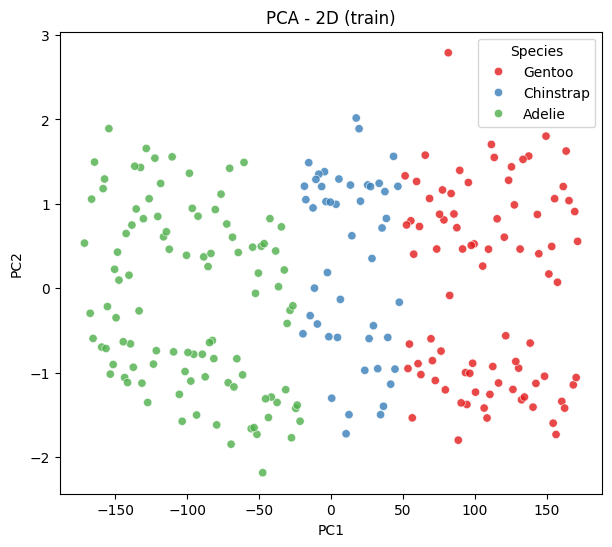

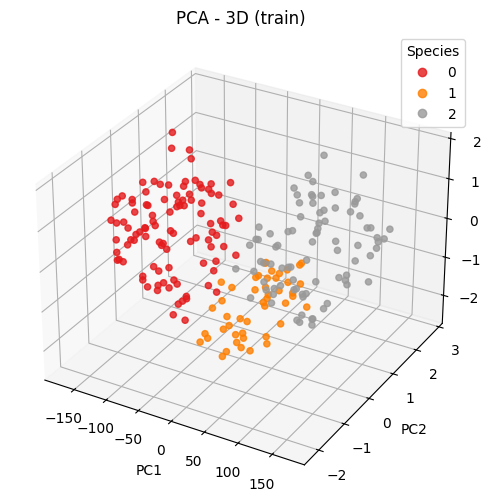

In [10]:
# === M3.1: PCA a 2 y 3 dimensiones ===
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA 2D
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_train)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y_train, palette="Set1", alpha=0.8)
plt.title("PCA - 2D (train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Species")
plt.show()

# PCA 3D
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_train)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2],
                     c=y_train.astype('category').cat.codes, cmap="Set1", alpha=0.8)
ax.set_title("PCA - 3D (train)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Species")
plt.show()


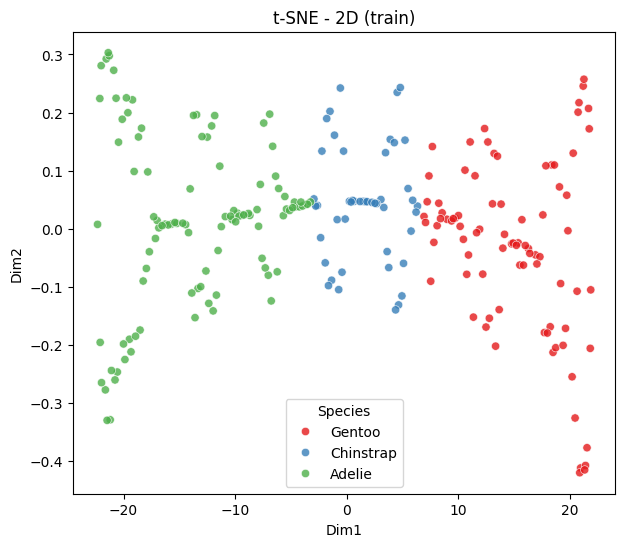

In [11]:
# === M3.2: t-SNE 2D ===
from sklearn.manifold import TSNE

tsne2 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne2 = tsne2.fit_transform(X_train)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_tsne2[:,0], y=X_tsne2[:,1], hue=y_train, palette="Set1", alpha=0.8)
plt.title("t-SNE - 2D (train)")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.legend(title="Species")
plt.show()


**Interpretación misión 3**


1. PCA 2D y 3D:

Se distinguen tres grupos: Adelie (verde) bien separado, Gentoo (rojo) más compacto y separado, y Chinstrap (azul) algo solapado entre Adelie y Gentoo.

El PCA logra capturar bastante la separación, aunque hay cierta superposición (normal en datos biológicos).

2. t-SNE 2D:

Refuerza la separación clara de Adelie y Gentoo.

Chinstrap aparece en la “franja intermedia”, lo que muestra que comparte características con ambos.

El método es no lineal, por eso logra un agrupamiento visual más nítido que PCA.

 Conclusión: existen grupos claros por especie, con Chinstrap como el más “difuso”. También se ven algunos puntos atípicos (posibles outliers).

## Misión 4 — Análisis de clusters

**Propósito.** Aplicar clustering para descubrir agrupaciones en los datos y compararlas con las especies reales.  

**Entradas:**  
- `X_train` (todas las features, escaladas).  
- Reducción a 2D/3D (PCA) de la Misión 3.  

**Pasos:**
1. Aplicar **KMeans** sobre el dataset completo (`X_train`).  
   - Usar el **método del codo** (inercia vs k) para estimar número óptimo de clusters.  
   - Entrenar con ese `k` y graficar clusters (2D PCA para visualizar).  
2. Repetir el clustering sobre el **espacio reducido (PCA 2D)**.  
3. Comparar resultados:  
   - ¿Coincide el número óptimo de clusters con el número de especies (3)?  
   - ¿Aparecen subgrupos dentro de una especie?  
   - ¿Se observan mezclas entre especies?  


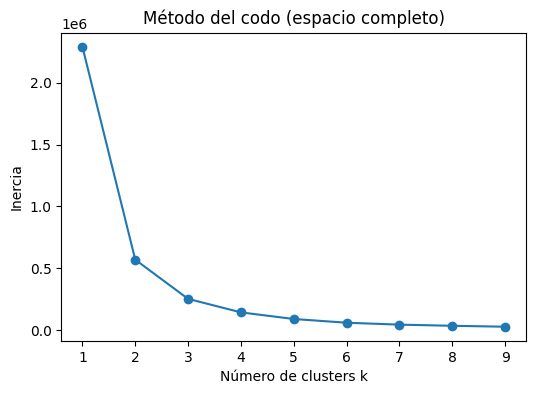

In [12]:
# === M4.1: KMeans y método del codo (espacio completo) ===
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker="o")
plt.title("Método del codo (espacio completo)")
plt.xlabel("Número de clusters k")
plt.ylabel("Inercia")
plt.show()


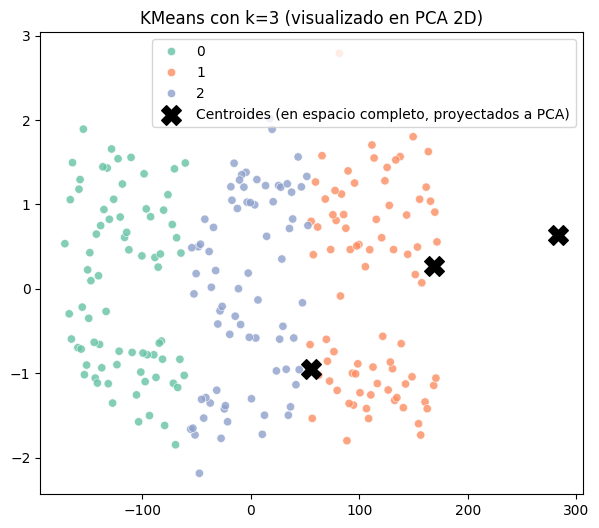

In [13]:
# Elegir k óptimo (a ojo según el codo, probablemente 3)
k_opt = 3
km_full = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters_full = km_full.fit_predict(X_train)

# Visualización en espacio PCA 2D
plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=clusters_full, palette="Set2", alpha=0.8)
plt.scatter(km_full.cluster_centers_[:,0], km_full.cluster_centers_[:,1],
            s=200, c="black", marker="X", label="Centroides (en espacio completo, proyectados a PCA)")
plt.title(f"KMeans con k={k_opt} (visualizado en PCA 2D)")
plt.legend()
plt.show()


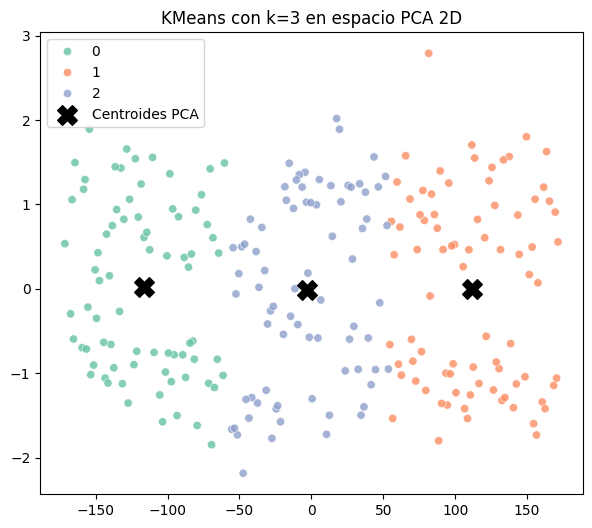

In [14]:
# === M4.2: KMeans en PCA 2D ===
km_pca = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters_pca = km_pca.fit_predict(X_pca2)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=clusters_pca, palette="Set2", alpha=0.8)
plt.scatter(km_pca.cluster_centers_[:,0], km_pca.cluster_centers_[:,1],
            s=200, c="black", marker="X", label="Centroides PCA")
plt.title(f"KMeans con k={k_opt} en espacio PCA 2D")
plt.legend()
plt.show()


## Conclusión — Misión 4 (Clustering)

**Resumen de resultados:**  
- El *método del codo* sugiere un número óptimo de **k = 3**, lo que coincide con las especies reales.  
- Con **KMeans en el espacio completo**, los clusters se proyectan de forma clara en PCA 2D, con centroides bien definidos.  
- Con **KMeans en el espacio PCA 2D**, los grupos se mantienen diferenciados, aunque **Chinstrap** aparece como el más difuso, solapándose en parte con Gentoo.  
- No se observan subgrupos fuertes dentro de cada especie, aunque hay algunos puntos atípicos en los bordes.

**Interpretación:**  
El clustering reproduce de manera coherente las **tres especies de pingüinos** presentes en el dataset.  
Esto valida que las características morfométricas (pico, aleta, masa corporal) contienen suficiente información para separar las especies.  
La ligera superposición de Chinstrap con otras especies refleja similitudes biológicas reales y posibles *outliers*.  

Con esto queda confirmada la robustez de los datos y se dejan listos los insumos para la **Misión 5 (predicción de especie)**.
